<a href="https://colab.research.google.com/github/Aymanelok/Portfolio/blob/main/NLP/Lab1_NLP_Text_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **This lab focuses on analyzing a BBC News dataset and implementing essential text preprocessing techniques.**

In [ ]:
import pandas as pd

df = pd.read_csv('./BBC_News.csv', sep=',')
print("Shape: ", df.shape)
df.head()

Shape:  (1493, 3)


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


# **Exploratory Data Analysis**

In [ ]:
print(df.columns)

Index(['ArticleId', 'Text', 'Category'], dtype='object')


### **TODO:** Print the different categories of articles present in the dataset. Hint: use the `.unique()` function

In [ ]:
print(df['Category'].unique)

<bound method Series.unique of 0            business
1            business
2            business
3                tech
4            business
            ...      
1488    entertainment
1489    entertainment
1490         business
1491             tech
1492             tech
Name: Category, Length: 1493, dtype: object>


### **TODO:** Print the list of row indices where the Text column in the dataset contains missing (null) values

In [ ]:
print(df[df.Text.isnull()].index.tolist)

<bound method IndexOpsMixin.tolist of Index([687], dtype='int64')>


### **TODO:** Remove all rows in the dataset that contain missing (NaN) values.


In [ ]:
df.dropna(inplace=True)
df.shape

(1492, 3)

### *Question:* We usually call reset_index(drop=True) after removing rows from a dataset, what are 'drop' and 'inplace' args used for in the code bellow ?

inplace=true , on remplace la valeur suivante par la valeur NaN supprimé

In [ ]:
r_i=df.reset_index(drop=True, inplace=True)
df.shape

(1492, 3)

### **TODO:** Clean the dataset by removing duplicate entries, reset the index, display the new dataset size, and retrieve the list of news categories.

In [ ]:
df=df.drop_duplicates()
r_i
print(df.shape)
print(df['Category'].unique)

(1490, 3)
<bound method Series.unique of 0            business
1            business
2            business
3                tech
4            business
            ...      
1487    entertainment
1488    entertainment
1489         business
1490             tech
1491             tech
Name: Category, Length: 1490, dtype: object>


### **TODO:** Display the number of articles per `category`

Hint: use `.groupby()` function

In [ ]:
df.groupby('Category').size()

,0
Category,
business,336
entertainment,273
politics,274
sport,346
tech,261


### **TODO:** Print the mean length (number of characters) of the `Text` column

Hint: use the `.mean()` function

In [ ]:
print(df['Text'].str.len().mean())

2233.461744966443


### **TODO:** Plot the histogram of the text lengths (i.e., number of characters per text)

Hinr: use the `.hist()` function

<Axes: >

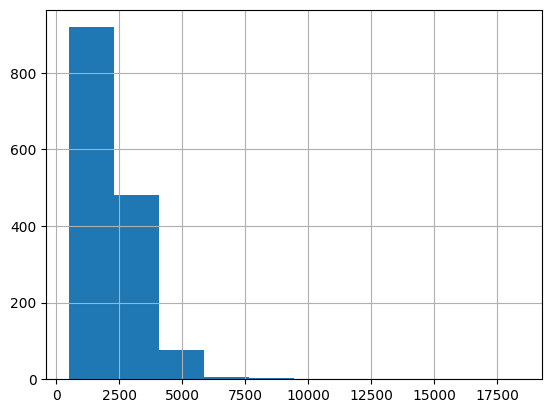

In [ ]:
df['Text'].str.len().hist()

### **TODO:** Add a new column `content_len` describing the number of words (splitting according to whitespaces)

In [ ]:
df['content_len'] = df['Text'].str.split(" ").str.len()
df

,ArticleId,Text,Category,content_len
0,1833,worldcom ex-boss launches defence lawyers defe...,business,324
1,154,german business confidence slides german busin...,business,348
2,1101,bbc poll indicates economic gloom citizens in ...,business,551
3,1976,lifestyle governs mobile choice faster bett...,tech,692
4,917,enron bosses in $168m payout eighteen former e...,business,381
...,...,...,...,...
1487,857,double eviction from big brother model caprice...,entertainment,237
1488,325,dj double act revamp chart show dj duo jk and ...,entertainment,619
1489,1590,weak dollar hits reuters revenues at media gro...,business,252
1490,1587,apple ipod family expands market apple has exp...,tech,595


### **TODO:** Print statistics of `content_length` per category. Hint: use the `.describe()` function

In [ ]:
df.groupby('Category')['content_len'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
business,336.0,357.913690,144.528451,149.0,271.50,326.0,417.25,983.0
entertainment,273.0,360.531136,220.957043,155.0,248.00,295.0,412.00,2616.0
politics,274.0,484.135036,275.419161,94.0,341.25,477.5,572.00,3519.0
sport,346.0,361.667630,199.663375,122.0,226.00,314.5,451.00,1778.0
tech,261.0,538.122605,230.808446,192.0,368.00,483.0,684.00,1692.0


# **Text Preprocessing**

### In the following, we will apply a conventional text preprocessing pipeline on a sample from the dataset. For each operation, you should compare the input and output tokens, describe the operation purpose, and give some of its pros and cons.

In [ ]:
! pip install nltk spacy scikit-learn

## Tokenization

In [ ]:
import nltk
from nltk.tokenize import (
    word_tokenize, sent_tokenize,
    TreebankWordTokenizer, TweetTokenizer, WhitespaceTokenizer, MWETokenizer
)
nltk.download('punkt_tab')
# Example text with contractions, punctuation, social media elements, and a multi-word expression
example_text = "Hey @user! I can't believe it's 2025... Visit https://example.com for details. New York is amazing! 😊"

print("WhitespaceTokenizer")
tokens = WhitespaceTokenizer().tokenize(example_text)
print('Tokens: ', tokens)
print("Vocabulary size: ", len(set(tokens)))
print('='*20)

print("word_tokenize")
tokens = word_tokenize(example_text)
print('Tokens: ', tokens)
print("Vocabulary size: ", len(set(tokens)))
print('='*20)

print("sent_tokenize")
tokens = sent_tokenize(example_text)
print('Tokens: ', tokens)
print("Vocabulary size: ", len(set(tokens)))
print('='*20)

print("TreebankWordTokenizer")
tokens = TreebankWordTokenizer().tokenize(example_text)
print('Tokens: ', tokens)
print("Vocabulary size: ", len(set(tokens)))
print('='*20)

print("TweetTokenizer")
tokens = TweetTokenizer().tokenize(example_text)
print('Tokens: ', tokens)
print("Vocabulary size: ", len(set(tokens)))
print('='*20)

print("MWETokenizer")
mwe_tokenizer = MWETokenizer([('New', 'York')])
tokens = mwe_tokenizer.tokenize(example_text.split())
print('Tokens: ', tokens)
print("Vocabulary size: ", len(set(tokens)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


WhitespaceTokenizer
Tokens:  ['Hey', '@user!', 'I', "can't", 'believe', "it's", '2025...', 'Visit', 'https://example.com', 'for', 'details.', 'New', 'York', 'is', 'amazing!', '😊']
Vocabulary size:  16
word_tokenize
Tokens:  ['Hey', '@', 'user', '!', 'I', 'ca', "n't", 'believe', 'it', "'s", '2025', '...', 'Visit', 'https', ':', '//example.com', 'for', 'details', '.', 'New', 'York', 'is', 'amazing', '!', '😊']
Vocabulary size:  24
sent_tokenize
Tokens:  ['Hey @user!', "I can't believe it's 2025... Visit https://example.com for details.", 'New York is amazing!', '😊']
Vocabulary size:  4
TreebankWordTokenizer
Tokens:  ['Hey', '@', 'user', '!', 'I', 'ca', "n't", 'believe', 'it', "'s", '2025', '...', 'Visit', 'https', ':', '//example.com', 'for', 'details.', 'New', 'York', 'is', 'amazing', '!', '😊']
Vocabulary size:  23
TweetTokenizer
Tokens:  ['Hey', '@user', '!', 'I', "can't", 'believe', "it's", '2025', '...', 'Visit', 'https://example.com', 'for', 'details', '.', 'New', 'York', 'is', 'amaz

### For the following tasks, we use `TreebankWordTokenizer` on `df.Text[10]`.

In [ ]:
tokenizer = TreebankWordTokenizer()
tokens = tokenizer.tokenize(df.Text[10])
tokens

['blair',
 'rejects',
 'iraq',
 'advice',
 'calls',
 'tony',
 'blair',
 'has',
 'rejected',
 'calls',
 'for',
 'the',
 'publication',
 'of',
 'advice',
 'on',
 'the',
 'legality',
 'of',
 'the',
 'iraq',
 'war',
 'amid',
 'growing',
 'calls',
 'for',
 'an',
 'investigation.',
 'the',
 'prime',
 'minister',
 'told',
 'his',
 'monthly',
 'press',
 'conference',
 'the',
 'matter',
 'had',
 'been',
 'dealt',
 'with',
 'by',
 'the',
 'attorney',
 'general.',
 'earlier',
 'conservative',
 'mp',
 'michael',
 'mates',
 'joined',
 'calls',
 'for',
 'a',
 'probe',
 'into',
 'claims',
 'lord',
 'goldsmith',
 's',
 'statement',
 'to',
 'parliament',
 'was',
 'drawn',
 'up',
 'at',
 'number',
 '10.',
 'mr',
 'blair',
 'said',
 'the',
 'statement',
 'was',
 'a',
 'fair',
 'summary',
 'of',
 'lord',
 'goldsmith',
 's',
 'opinion.',
 'that',
 's',
 'what',
 'he',
 '(',
 'lord',
 'goldsmith',
 ')',
 'said',
 'and',
 'that',
 's',
 'what',
 'i',
 'say.',
 'he',
 'has',
 'dealt',
 'with',
 'this',
 'time

## Removing stop-words

In [ ]:
import string

from nltk.corpus import stopwords as stop_nltk

import spacy
from spacy.lang.en import stop_words as stop_spacy

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


nltk.download('stopwords')
nltk_stopwords = set(stop_nltk.words('english'))

spacy.load('en_core_web_sm')
spacy_stopwords = stop_spacy.STOP_WORDS

sklearn_stopwords = set(ENGLISH_STOP_WORDS)

combined_stopwords = nltk_stopwords | spacy_stopwords | sklearn_stopwords

punctuation = set(string.punctuation)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### **TODO:** Remove all tokens from `df.Text[10]` that are in `excluded` list

In [ ]:
excluded = list(combined_stopwords | punctuation)

tokens_sample_example = [w for w in tokens if w not in excluded]
tokens_sample_example

['blair',
 'rejects',
 'iraq',
 'advice',
 'calls',
 'tony',
 'blair',
 'rejected',
 'calls',
 'publication',
 'advice',
 'legality',
 'iraq',
 'war',
 'amid',
 'growing',
 'calls',
 'investigation.',
 'prime',
 'minister',
 'told',
 'monthly',
 'press',
 'conference',
 'matter',
 'dealt',
 'attorney',
 'general.',
 'earlier',
 'conservative',
 'mp',
 'michael',
 'mates',
 'joined',
 'calls',
 'probe',
 'claims',
 'lord',
 'goldsmith',
 'statement',
 'parliament',
 'drawn',
 'number',
 '10.',
 'mr',
 'blair',
 'said',
 'statement',
 'fair',
 'summary',
 'lord',
 'goldsmith',
 'opinion.',
 'lord',
 'goldsmith',
 'said',
 'say.',
 'dealt',
 'time',
 'time',
 'time',
 'mr',
 'blair',
 'told',
 'monthly',
 'news',
 'conference',
 'downing',
 'street.',
 'refused',
 'answer',
 'questions',
 'issue',
 'saying',
 'dealt',
 'literally',
 'scores',
 'times',
 'position',
 'changed',
 'lord',
 'goldsmith',
 'denied',
 'leaned',
 'says',
 'words',
 'written',
 'his.',
 'government',
 'refuses',
 

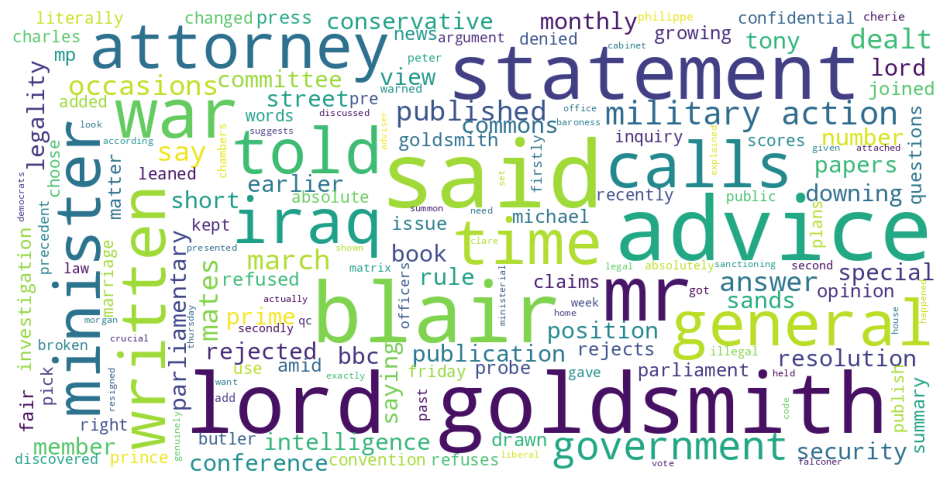

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

full_texts = ' '.join(tokens_sample_example)

wordcloud = WordCloud(
        background_color='white',
        max_words=200,
        max_font_size=40,
        scale=3
    ).generate(full_texts)

fig = plt.figure(1, figsize=(12, 12))
plt.axis('off')

plt.imshow(wordcloud)
plt.show()

## Stemming

In [ ]:
from nltk.stem.porter import *

stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(token) for token in tokens_sample_example]
stemmed_tokens

['blair',
 'reject',
 'iraq',
 'advic',
 'call',
 'toni',
 'blair',
 'reject',
 'call',
 'public',
 'advic',
 'legal',
 'iraq',
 'war',
 'amid',
 'grow',
 'call',
 'investigation.',
 'prime',
 'minist',
 'told',
 'monthli',
 'press',
 'confer',
 'matter',
 'dealt',
 'attorney',
 'general.',
 'earlier',
 'conserv',
 'mp',
 'michael',
 'mate',
 'join',
 'call',
 'probe',
 'claim',
 'lord',
 'goldsmith',
 'statement',
 'parliament',
 'drawn',
 'number',
 '10.',
 'mr',
 'blair',
 'said',
 'statement',
 'fair',
 'summari',
 'lord',
 'goldsmith',
 'opinion.',
 'lord',
 'goldsmith',
 'said',
 'say.',
 'dealt',
 'time',
 'time',
 'time',
 'mr',
 'blair',
 'told',
 'monthli',
 'news',
 'confer',
 'down',
 'street.',
 'refus',
 'answer',
 'question',
 'issu',
 'say',
 'dealt',
 'liter',
 'score',
 'time',
 'posit',
 'chang',
 'lord',
 'goldsmith',
 'deni',
 'lean',
 'say',
 'word',
 'written',
 'his.',
 'govern',
 'refus',
 'publish',
 'advic',
 'legal',
 'war',
 'say',
 'paper',
 'kept',
 'conf

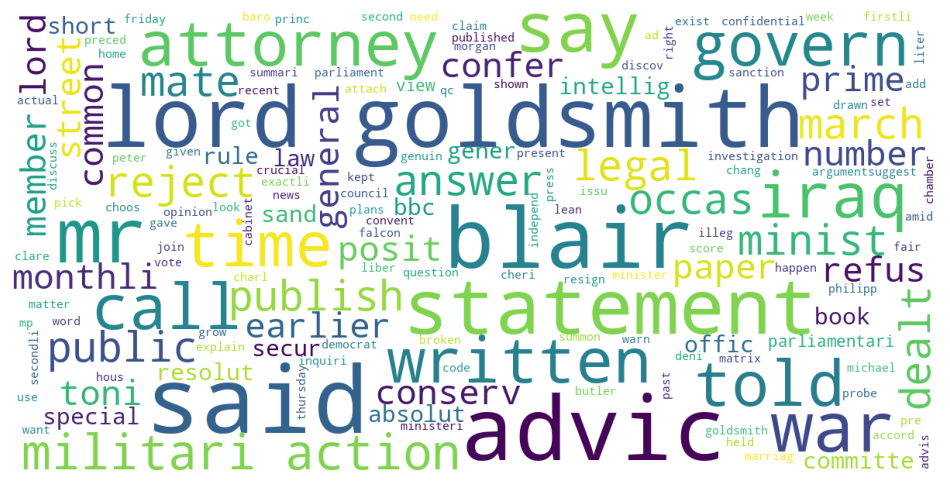

In [ ]:
full_texts = ' '.join(stemmed_tokens)

wordcloud = WordCloud(
        background_color='white',
        max_words=300,
        max_font_size=40,
        scale=3
    ).generate(full_texts)

fig = plt.figure(1, figsize=(12, 12))
plt.axis('off')

plt.imshow(wordcloud)
plt.show()

## Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
wordnet_lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [wordnet_lemmatizer.lemmatize(w) for w in tokens_sample_example]
lemmatized_tokens

[nltk_data] Downloading package wordnet to /root/nltk_data...


['blair',
 'reject',
 'iraq',
 'advice',
 'call',
 'tony',
 'blair',
 'rejected',
 'call',
 'publication',
 'advice',
 'legality',
 'iraq',
 'war',
 'amid',
 'growing',
 'call',
 'investigation.',
 'prime',
 'minister',
 'told',
 'monthly',
 'press',
 'conference',
 'matter',
 'dealt',
 'attorney',
 'general.',
 'earlier',
 'conservative',
 'mp',
 'michael',
 'mate',
 'joined',
 'call',
 'probe',
 'claim',
 'lord',
 'goldsmith',
 'statement',
 'parliament',
 'drawn',
 'number',
 '10.',
 'mr',
 'blair',
 'said',
 'statement',
 'fair',
 'summary',
 'lord',
 'goldsmith',
 'opinion.',
 'lord',
 'goldsmith',
 'said',
 'say.',
 'dealt',
 'time',
 'time',
 'time',
 'mr',
 'blair',
 'told',
 'monthly',
 'news',
 'conference',
 'downing',
 'street.',
 'refused',
 'answer',
 'question',
 'issue',
 'saying',
 'dealt',
 'literally',
 'score',
 'time',
 'position',
 'changed',
 'lord',
 'goldsmith',
 'denied',
 'leaned',
 'say',
 'word',
 'written',
 'his.',
 'government',
 'refuse',
 'publish',
 '

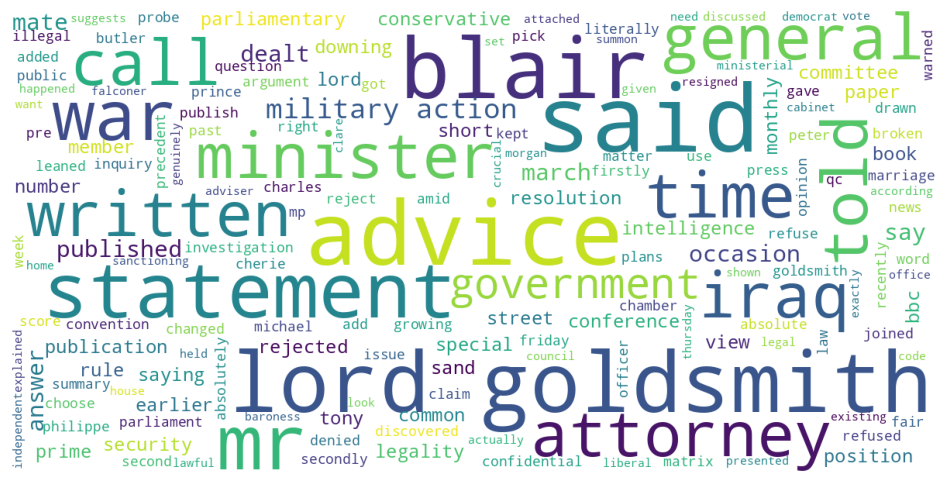

In [ ]:
full_texts = ' '.join(lemmatized_tokens)

wordcloud = WordCloud(
        background_color='white',
        max_words=300,
        max_font_size=40,
        scale=3
    ).generate(full_texts)

fig = plt.figure(1, figsize=(12, 12))
plt.axis('off')

plt.imshow(wordcloud)
plt.show()

### *Question:* What's the goal behind the below code?

to show the token or word that s been lemmatized

In [ ]:
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

pos_tags = nltk.pos_tag(tokens_sample_example)

lemmatized_tokens_tagged = [wordnet_lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]

lemmatized_tokens_tagged

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


['blair',
 'reject',
 'iraq',
 'advice',
 'call',
 'tony',
 'blair',
 'reject',
 'call',
 'publication',
 'advice',
 'legality',
 'iraq',
 'war',
 'amid',
 'grow',
 'call',
 'investigation.',
 'prime',
 'minister',
 'tell',
 'monthly',
 'press',
 'conference',
 'matter',
 'deal',
 'attorney',
 'general.',
 'earlier',
 'conservative',
 'mp',
 'michael',
 'mate',
 'join',
 'call',
 'probe',
 'claim',
 'lord',
 'goldsmith',
 'statement',
 'parliament',
 'draw',
 'number',
 '10.',
 'mr',
 'blair',
 'say',
 'statement',
 'fair',
 'summary',
 'lord',
 'goldsmith',
 'opinion.',
 'lord',
 'goldsmith',
 'say',
 'say.',
 'dealt',
 'time',
 'time',
 'time',
 'mr',
 'blair',
 'tell',
 'monthly',
 'news',
 'conference',
 'down',
 'street.',
 'refuse',
 'answer',
 'question',
 'issue',
 'say',
 'dealt',
 'literally',
 'score',
 'time',
 'position',
 'change',
 'lord',
 'goldsmith',
 'deny',
 'lean',
 'say',
 'word',
 'write',
 'his.',
 'government',
 'refuse',
 'publish',
 'advice',
 'legality',
 'w

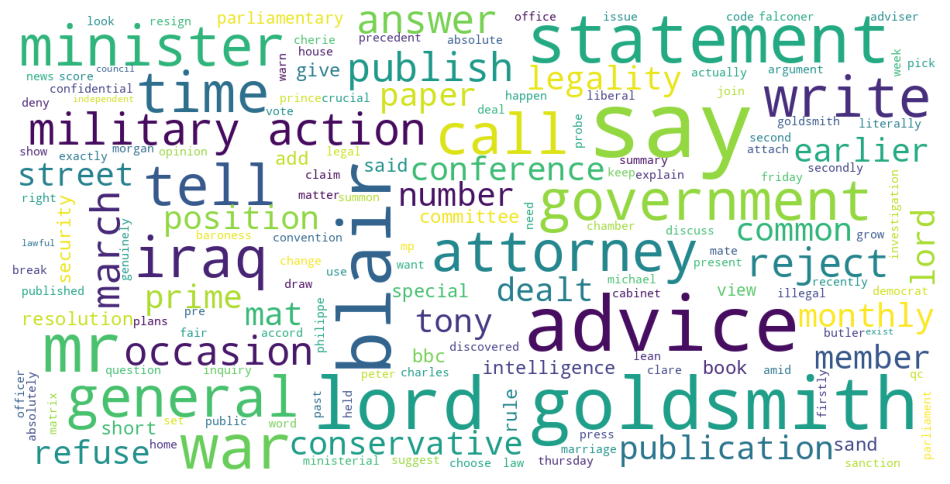

In [ ]:
full_texts = ' '.join(lemmatized_tokens_tagged)

wordcloud = WordCloud(
        background_color='white',
        max_words=300,
        max_font_size=40,
        scale=3
    ).generate(full_texts)

fig = plt.figure(1, figsize=(12, 12))
plt.axis('off')

plt.imshow(wordcloud)
plt.show()

### *Question:* What are the differences between stemming and lemmatization?

Stemming: Removes prefixes/suffixes, potentially creating non-words.

Lemmatization: Returns dictionary base form, always a real word, often using POS tags.


#**END**